In [ ]:
!python setup_colab.py

# **Linear SVR for Rental Price Prediction**

## ***Overview***

This notebook presents the end-to-end process of training and evaluating ***Linear Support Vector Regression (Linear SVR) models*** for predicting apartment rental prices. The primary objective is to analyze the impact of including the feature `baseRent` on model performance.

The workflow begins with loading preprocessed datasets, followed by constructing two feature configurations: one excluding `baseRent` and one including it. For each configuration, a Linear SVR model is trained using a pipeline with feature scaling and hyperparameter tuning via GridSearchCV.

The models are then evaluated and compared using multiple metrics, including $MAE$, $RMSE$, and $R^2$, along with visualization techniques to analyze prediction behavior and error distribution. Based on the comparison results, the best-performing model is selected.

Finally, the selected model is retrained on the combined training and validation datasets to maximize learning capacity, and its performance is assessed on the test set to evaluate generalization ability.

## ***Table of Contents***
1. Setup & Dependencies
2. Data Acquisition
3. Feature - Target Split
4. SVR Model Training without `baseRent` (`svm_model_1`)
5. SVR Model Training with `baseRent` (`svm_model_2`)
6. Model Evaluation & Comparison
7. Final Model Training & Testing

# **1. Setup & Dependencies**

This section outlines the initial setup required for the notebook, including environment configuration and the installation of necessary libraries for data processing and model training.

## ***1.1. Environment Setup (Google Colab)***

This subsection initializes the runtime environment for the notebook:
- Verifies the Python executable being used
- Mounts Google Drive to access datasets and save trained models

Ensure that Google Drive is properly mounted before proceeding with data loading and model training.

In [ ]:
import sys
print(sys.executable)

/usr/bin/python3
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ***1.2. Library Installation***

This subsection installs all required libraries for model training, and evaluation. The following libraries are used:

- **pandas, numpy**: data manipulation and numerical computation  
- **scikit-learn**: machine learning framework, including model (`LinearSVR`), model selection (`GridSearchCV`), and evaluation metrics  
- **matplotlib, seaborn**: data visualization and exploratory analysis  
- **os**: file system operations (path handling, directory management)

In [43]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.base import clone

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **2. Data Acquisition**

This section covers data loading and provides an overview of the dataset.

## ***2.1. Load Train, Validation and Test Sets***

This section is responsible for loading the prepared datasets used for model training and evaluation. The data has been preprocessed and split into three subsets:

- **Training set**: used to fit the model  
- **Validation set**: used for hyperparameter tuning (GridSearchCV)  
- **Test set**: used for final evaluation  

The datasets are loaded from the predefined data directory stored in Google Drive.

In [ ]:
train_df = pd.read_csv("features/processed/train.csv")
val_df = pd.read_csv("features/processed/val.csv")
test_df = pd.read_csv("features/processed/test.csv")

## ***2.2. Dataset Overview***

This step verifies the size and structure of each dataset split to ensure correctness after preprocessing and data splitting.

In [45]:
def summarize_dataset(name, df, total):
    print(f"{name} set:")
    print(f"  Samples : {df.shape[0]:,}")
    print(f"  Features: {df.shape[1]}")
    print(f"  Ratio   : {df.shape[0] / total:.2%}\n")

total_samples = len(train_df) + len(val_df) + len(test_df)

summarize_dataset("Train", train_df, total_samples)
summarize_dataset("Validation", val_df, total_samples)
summarize_dataset("Test", test_df, total_samples)

Train set:
  Samples : 172,064
  Features: 65
  Ratio   : 64.00%

Validation set:
  Samples : 43,016
  Features: 65
  Ratio   : 16.00%

Test set:
  Samples : 53,770
  Features: 65
  Ratio   : 20.00%



## ***2.3. Feature Overview***

This step provides an overview of the dataset schema, including feature types and data completeness.

In [46]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172064 entries, 0 to 172063
Data columns (total 65 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   serviceCharge                                 172064 non-null  float64
 1   picturecount                                  172064 non-null  float64
 2   pricetrend                                    172064 non-null  float64
 3   yearConstructed                               172064 non-null  float64
 4   baseRent                                      172064 non-null  float64
 5   livingSpace                                   172064 non-null  float64
 6   noRooms                                       172064 non-null  float64
 7   floor                                         172064 non-null  float64
 8   numberOfFloors                                172064 non-null  float64
 9   newlyConst                                    17

# **3. Feature – Target Split**

In this step, the dataset is split into input features (**x**) and target variable (**y**), where the target is consistently defined as:

- **Target**: `totalRent`

Two feature configurations are prepared:

- **Without `baseRent`**: excludes `baseRent` to evaluate model performance using only indirect features  
- **With `baseRent`**: includes `baseRent` as an input feature  

This setup enables a controlled comparison to assess the contribution of `baseRent` in predicting `totalRent`.

## ***3.1. Without `baseRent`***

In [47]:
x_train_without_baseRent = train_df.drop(columns=["totalRent", "baseRent"])
y_train_without_baseRent = train_df["totalRent"]

x_val_without_baseRent = val_df.drop(columns=["totalRent","baseRent"])
y_val_without_baseRent = val_df["totalRent"]

x_test_without_baseRent = test_df.drop(columns=["totalRent", "baseRent"])
y_test_without_baseRent = test_df["totalRent"]

## ***3.2. With `baseRent`***

In [48]:
x_train_with_baseRent = train_df.drop(columns=["totalRent"])
y_train_with_baseRent = train_df["totalRent"]

x_val_with_baseRent = val_df.drop(columns=["totalRent"])
y_val_with_baseRent = val_df["totalRent"]

x_test_with_baseRent = test_df.drop(columns=["totalRent"])
y_test_with_baseRent = test_df["totalRent"]

# **4. SVR Model Training without `baseRent` (`svm_model_1`)**

This section presents the training process of the Linear SVR model without the `baseRent` feature, aiming to evaluate how well the model performs when relying only on indirect attributes. A machine learning pipeline is constructed, incorporating feature scaling and a Linear SVR estimator.

Hyperparameter tuning is performed using GridSearchCV to identify the optimal configuration based on validation performance. The trained model is then evaluated on the validation set using multiple metrics, including MAE, RMSE, and $R^2$, providing a baseline for comparison with the model that includes the `baseRent` feature.

## ***4.1. Hyperparameter Tuning with GridSearchCV***

In this step, a machine learning pipeline is constructed, combining feature standardization using StandardScaler and a Linear SVR model. To optimize model performance, hyperparameter tuning is performed using GridSearchCV over a predefined search space, including parameters such as the regularization strength ($C$), epsilon-insensitive loss margin ($\epsilon$), tolerance, and maximum number of iterations.

The grid search is conducted using cross-validation, with $R^2$ selected as the evaluation metric. This process identifies the optimal set of hyperparameters that maximizes the model’s ability to explain variance on unseen data.

In [49]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVR(random_state=36))
])

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.0, 0.1, 0.5],
    "model__tol": [1e-3, 1e-2],
    "model__max_iter": [2000, 5000],
    "model__loss": ["squared_epsilon_insensitive"],
    "model__dual": [False]
}

grid_1 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_1.fit(x_train_without_baseRent, y_train_without_baseRent)


Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LinearSVR(random_state=36))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10], 'model__dual': [False],
                         'model__epsilon': [0.0, 0.1, 0.5],
                         'model__loss': ['squared_epsilon_insensitive'],
                         'model__max_iter': [2000, 5000],
                         'model__tol': [0.001, 0.01]},
             scoring='r2', verbose=1)

The grid search results identify the optimal set of hyperparameters for the Linear SVR model. The selected configuration achieves the highest cross-validated $R^2$ score among all candidates, indicating the best trade-off between bias and variance within the defined search space.

Based on these results, the best-performing pipeline is retrieved and used as the final model for subsequent validation and analysis.

In [50]:
print("Best params:", grid_1.best_params_)
print("Best R2:", grid_1.best_score_)

Best params: {'model__C': 10, 'model__dual': False, 'model__epsilon': 0.5, 'model__loss': 'squared_epsilon_insensitive', 'model__max_iter': 2000, 'model__tol': 0.001}
Best R2: 0.4871642260985399


In [51]:
svm_model_1 = grid_1.best_estimator_

## ***4.2. Validation Performance Evaluation***

In this step, the trained model is evaluated on the validation set using MAE, RMSE, and $R^2$ to assess its generalization performance. The results serve as a baseline for comparison with the model that includes the `baseRent` feature.

In [52]:
y_val_pred_1 = svm_model_1.predict(x_val_without_baseRent)

mae_val_1 = mean_absolute_error(y_val_without_baseRent, y_val_pred_1)
mse_val_1 = mean_squared_error(y_val_without_baseRent, y_val_pred_1)
rmse_val_1 = np.sqrt(mse_val_1)
r2_val_1 = r2_score(y_val_without_baseRent, y_val_pred_1)

print(f"MAE  : {mae_val_1:.4f}")
print(f"MSE  : {mse_val_1:.4f}")
print(f"RMSE : {rmse_val_1:.4f}")
print(f"R2   : {r2_val_1:.4f}")

MAE  : 153.9144
MSE  : 48904.8007
RMSE : 221.1443
R2   : 0.4913


The validation results indicate that the model achieves a moderate level of performance, with relatively high error values (MAE and RMSE) and a modest $R^2$ score. This suggests that, without the `baseRent` feature, the model is limited in its ability to accurately capture the variation in rental prices.

These findings highlight the importance of key pricing-related features and motivate further evaluation using an extended feature set. The results obtained here will serve as a baseline for comparison with the model that includes the `baseRent` feature.

# **5. SVR Model Training with `baseRent` (`svm_model_2`)**

This section presents the training process of the Linear SVR model with the `baseRent` feature, aiming to evaluate how the inclusion of direct pricing information improves predictive performance. A machine learning pipeline is constructed, incorporating feature scaling and a Linear SVR estimator.

Hyperparameter tuning is performed using GridSearchCV to identify the optimal configuration based on validation performance. The trained model is then evaluated on the validation set using multiple metrics, including MAE, RMSE, and $R^2$, enabling a direct comparison with the baseline model that excludes the `baseRent` feature.

## ***5.1. Hyperparameter Tuning with GridSearchCV***

In this step, a machine learning pipeline is constructed, combining feature standardization using StandardScaler and a Linear SVR model. Hyperparameter tuning is performed using GridSearchCV over a predefined search space, including parameters such as the regularization strength ($C$), epsilon-insensitive loss margin ($\epsilon$), tolerance, and maximum number of iterations.

The grid search is conducted using cross-validation, with $R^2$ selected as the evaluation metric. This process identifies the optimal set of hyperparameters that maximizes the model’s ability to capture variance in rental prices when the `baseRent` feature is included.

In [53]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVR(random_state=36))
])

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.0, 0.1, 0.5],
    "model__tol": [1e-3, 1e-2],
    "model__max_iter": [2000, 5000],
    "model__loss": ["squared_epsilon_insensitive"],
    "model__dual": [False]
}

grid_2 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_2.fit(x_train_with_baseRent, y_train_with_baseRent)


Fitting 3 folds for each of 36 candidates, totalling 108 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LinearSVR(random_state=36))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10], 'model__dual': [False],
                         'model__epsilon': [0.0, 0.1, 0.5],
                         'model__loss': ['squared_epsilon_insensitive'],
                         'model__max_iter': [2000, 5000],
                         'model__tol': [0.001, 0.01]},
             scoring='r2', verbose=1)

The grid search results identify the optimal set of hyperparameters for the Linear SVR model. The selected configuration achieves a significantly higher cross-validated $R^2$ score compared to the baseline model, indicating improved predictive capability when incorporating the `baseRent` feature.

Based on these results, the best-performing pipeline is retrieved and used as the final model for subsequent validation and analysis.

In [54]:
print("Best params:", grid_2.best_params_)
print("Best R2:", grid_2.best_score_)

Best params: {'model__C': 0.1, 'model__dual': False, 'model__epsilon': 0.0, 'model__loss': 'squared_epsilon_insensitive', 'model__max_iter': 2000, 'model__tol': 0.001}
Best R2: 0.7426190534069069


In [55]:
svm_model_2 = grid_2.best_estimator_

## ***5.2. Validation Performance Evaluation***

In this step, the trained model is evaluated on the validation set to assess its generalization performance. Predictions are generated and compared against the ground truth using multiple evaluation metrics, including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and $R^2$.

These metrics provide a comprehensive view of the model’s accuracy and error characteristics, allowing for a direct comparison with the baseline model trained without the `baseRent` feature.

In [56]:
y_val_pred_2 = svm_model_2.predict(x_val_with_baseRent)

mae_val_2 = mean_absolute_error(y_val_with_baseRent, y_val_pred_2)
mse_val_2 = mean_squared_error(y_val_with_baseRent, y_val_pred_2)
rmse_val_2 = np.sqrt(mse_val_2)
r2_val_2 = r2_score(y_val_with_baseRent, y_val_pred_2)

print(f"MAE  : {mae_val_2:.4f}")
print(f"MSE  : {mse_val_2:.4f}")
print(f"RMSE : {rmse_val_2:.4f}")
print(f"R2   : {r2_val_2:.4f}")

MAE  : 87.3710
MSE  : 24693.9420
RMSE : 157.1431
R2   : 0.7431


The validation results demonstrate a substantial improvement in model performance compared to the baseline. Both MAE and RMSE are significantly reduced, while the $R^2$ score increases notably, indicating a stronger ability to explain variance in rental prices.

This improvement confirms that the `baseRent` feature plays a critical role in capturing the underlying pricing structure. The model is able to make more accurate and stable predictions when direct pricing information is included, highlighting the importance of informative features in regression tasks.

# **6. Model Evaluation & Comparison**

This section provides a comprehensive comparison between the two trained models to evaluate the impact of including the `baseRent` feature. The comparison is conducted through quantitative metrics, prediction visualizations, and error analysis, offering both numerical and intuitive insights into model performance.

The goal is to identify the model that achieves better accuracy and generalization, and to understand the underlying reasons for the observed differences.

## ***6.1. Quantitative Comparison***


In [57]:
data = {
    "Model": ["svm_model_1", "svm_model_2"],
    "Note" : ["without feature baseRent", "with feature baseRent"],
    "MAE": [mae_val_1, mae_val_2],
    "MSE": [mse_val_1, mse_val_2],
    "RMSE": [rmse_val_1, rmse_val_2],
    "R2": [r2_val_1, r2_val_2]
}

df_metrics = pd.DataFrame(data)
print(df_metrics)

         Model                      Note         MAE           MSE  \
0  svm_model_1  without feature baseRent  153.914398  48904.800721   
1  svm_model_2     with feature baseRent   87.370998  24693.942016   

         RMSE        R2  
0  221.144298  0.491279  
1  157.143062  0.743127  


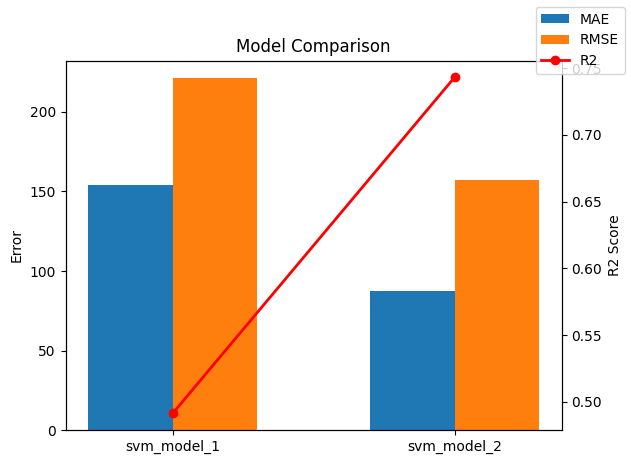

In [58]:
fig, ax1 = plt.subplots()

x = np.arange(len(df_metrics))
width = 0.3

# Left axis (Error)
ax1.bar(x - width/2, df_metrics["MAE"], width, label="MAE")
ax1.bar(x + width/2, df_metrics["RMSE"], width, label="RMSE")
ax1.set_ylabel("Error")

# Right axis (R2)
ax2 = ax1.twinx()
ax2.plot(x, df_metrics["R2"], color="red", marker="o", linewidth=2, label="R2")
ax2.set_ylabel("R2 Score")

# X-axis
plt.xticks(x, df_metrics["Model"])
plt.title("Model Comparison")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.show()

The quantitative results reveal a clear and consistent performance gap between the two models.

While the baseline model (excluding baseRent) achieves a moderate level of performance, the model incorporating baseRent demonstrates a substantial improvement across all evaluation metrics. Specifically, both MAE and RMSE are significantly reduced, while the R² score increases from a moderate to a strong explanatory level.

This gap is not merely incremental—it reflects a fundamental difference in the information available to the model. Without baseRent, the model must infer rental prices indirectly from structural and contextual features such as living space, location, and amenities. In contrast, when baseRent is included, the model gains access to a feature that is inherently tied to the target variable.

From a statistical perspective, this suggests that baseRent carries a dominant portion of the signal required to predict totalRent, effectively reducing the learning problem from complex inference to a more direct mapping.

## ***6.2. Prediction Behavior Analysis***


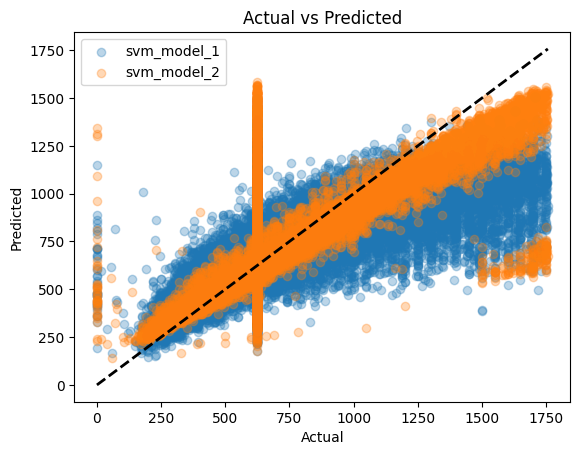

In [59]:
plt.figure()

plt.scatter(y_val_without_baseRent, y_val_pred_1, alpha=0.3, label="svm_model_1")
plt.scatter(y_val_with_baseRent, y_val_pred_2, alpha=0.3, label="svm_model_2")

plt.plot([y_val_with_baseRent.min(), y_val_with_baseRent.max()],
         [y_val_with_baseRent.min(), y_val_with_baseRent.max()],
         'k--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.title("Actual vs Predicted")

plt.show()

The scatter plot of actual versus predicted values provides deeper insight into model behavior beyond aggregate metrics.

The baseline model exhibits a wide dispersion around the diagonal line, indicating high variance in prediction errors. This suggests that the model struggles to consistently capture the relationship between input features and rental prices when relying solely on indirect signals.

In contrast, the model with baseRent produces predictions that align much more closely with the diagonal reference. The tighter clustering of points indicates improved accuracy and stability, particularly in mid-to-high rental ranges.

However, an important observation is that even the improved model shows slight deviations at extreme values. This suggests that while baseRent provides strong predictive power, the relationship between features and target is not perfectly linear, and certain edge cases remain difficult to model with a linear approach.

## ***6.3. Residual Analysis***


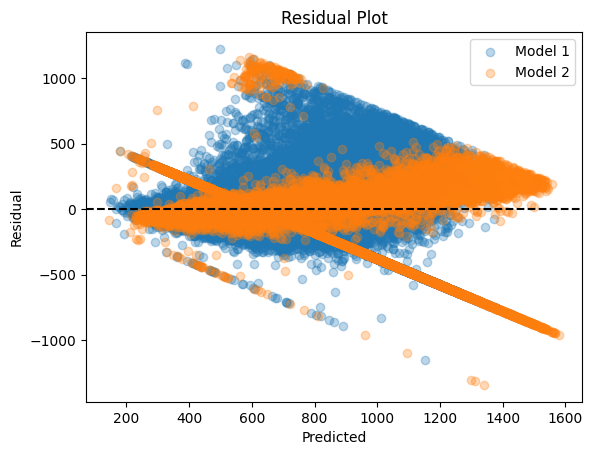

In [60]:
res1 = y_val_without_baseRent - y_val_pred_1
res2 = y_val_with_baseRent - y_val_pred_2

plt.figure()

plt.scatter(y_val_pred_1, res1, alpha=0.3, label="Model 1")
plt.scatter(y_val_pred_2, res2, alpha=0.3, label="Model 2")

plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.legend()
plt.title("Residual Plot")

plt.show()

Residual plots offer a more nuanced view of model bias and variance.

For the baseline model, residuals are widely dispersed and exhibit noticeable patterns, indicating systematic errors. This suggests that the model is underfitting and unable to fully capture the underlying structure of the data.

In contrast, the model including baseRent shows residuals that are more symmetrically distributed around zero, with a significantly narrower spread. This indicates:

- Reduced bias (errors centered around zero)
- Lower variance (more consistent predictions)
- Improved generalization behavior

However, a slight funnel-shaped pattern can still be observed, particularly at higher predicted values. This may indicate heteroscedasticity, where prediction errors increase with the magnitude of the target variable.

## ***6.4. Error Distribution Analysis***

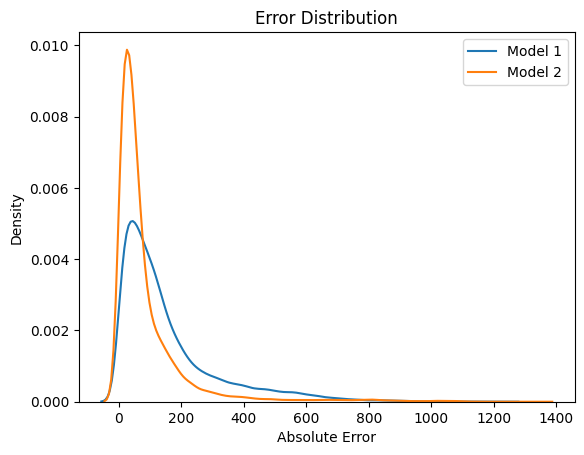

In [61]:
import seaborn as sns


error1 = abs(y_val_without_baseRent - y_val_pred_1)
error2 = abs(y_val_with_baseRent - y_val_pred_2)

plt.figure()

sns.kdeplot(error1, label="Model 1")
sns.kdeplot(error2, label="Model 2")

plt.xlabel("Absolute Error")
plt.title("Error Distribution")
plt.legend()

plt.show()

The error distribution further reinforces the previous findings.

The model with baseRent produces a sharply peaked distribution centered near zero, indicating that most predictions have relatively small errors. Additionally, the shorter tail suggests fewer extreme mispredictions.

In contrast, the baseline model exhibits a flatter and more spread-out distribution, with a longer tail. This indicates a higher frequency of large errors and less reliable predictions overall.

From a probabilistic standpoint, this implies that the inclusion of baseRent significantly reduces uncertainty in the prediction process.

## ***6.5. Critical Discussion***

Although the performance improvement is substantial, it is important to interpret the results carefully.

The feature baseRent is not just correlated with totalRent, it is likely a direct component of it. This introduces a potential information leakage scenario, where the model is effectively learning a near-deterministic relationship.

As a result, the high performance of the second model should not be interpreted purely as superior learning capability, but rather as a consequence of having access to highly informative (and possibly redundant) input data.

From a practical perspective:

- If the goal is to estimate totalRent when baseRent is already known $\rightarrow$ the second model is valid and useful.
- If the goal is to predict rental prices from independent property features $\rightarrow$ the baseline model (or a modified version without pricing features) is more meaningful.

This distinction is crucial for correctly framing the modeling objective.

# **7. Final Model Training & Testing**

This section presents the final stage of the modeling process. After selecting the best-performing model from the previous comparison, the model is retrained using the combined training and validation datasets to maximize learning capacity.

The retrained model is then evaluated on both the training set and the test set to assess its fitting behavior and generalization performance.

## ***7.1. Training Strategy***

After identifying the best-performing configuration, the model is retrained using the combined training and validation datasets.

This step increases the effective training size, allowing the model to learn from all available data once hyperparameter tuning is complete. By eliminating the validation split at this stage, the model maximizes its exposure to the data distribution.

This approach is standard in machine learning workflows, where validation is used only for model selection, and final training leverages the full dataset.

In [62]:
x_train = pd.concat([x_train_with_baseRent, x_val_with_baseRent])
y_train = pd.concat([y_train_with_baseRent, y_val_with_baseRent])

x_test = x_test_with_baseRent
y_test = y_test_with_baseRent

## ***7.2. Training Performance Analysis***


In [63]:
svm_model = clone(svm_model_2)
svm_model.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LinearSVR(C=0.1, dual=False,
                           loss='squared_epsilon_insensitive', max_iter=2000,
                           random_state=36, tol=0.001))])

In [64]:
y_train_pred = svm_model.predict(x_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print("="*10 + " TRAINING SET " + "="*10)
print(f"MAE  (train): {mae_train:.4f}")
print(f"MSE  (train): {mse_train:.4f}")
print(f"RMSE (train): {rmse_train:.4f}")
print(f"R2   (train): {r2_train:.4f}")

========== TRAINING SET ==========
MAE  (train): 87.5743
MSE  (train): 24810.4566
RMSE (train): 157.5134
R2   (train): 0.7430


The model achieves strong performance on the combined training set, as reflected by low error metrics and a high $R^2$ score.

However, it is important to note that strong training performance alone is not sufficient to assess model quality. A model that performs well on training data may still suffer from overfitting if it fails to generalize.

Given that the selected model is relatively simple (Linear SVR) and the feature set is well-structured, the risk of severe overfitting is mitigated, but not entirely eliminated.

## ***7.3. Test Set Evaluation***

In [65]:
y_test_pred = svm_model.predict(x_test)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("="*10 + " TESTING SET " + "="*10)
print(f"MAE  : {mae_test:.4f}")
print(f"MSE  : {mse_test:.4f}")
print(f"RMSE : {rmse_test:.4f}")
print(f"R2   : {r2_test:.4f}")

========== TESTING SET ==========
MAE  : 87.7496
MSE  : 24961.5858
RMSE : 157.9924
R2   : 0.7461


In this step, the final model is evaluated on the test set, which has not been used during training or validation. This evaluation provides an unbiased estimate of the model’s generalization performance on unseen data.

The results demonstrate that the model maintains strong predictive performance, with low error values and a high $R^2$ score, confirming its ability to generalize effectively beyond the training data.

## ***7.4. Model Evaluation & Analysis***

### 7.4.1. *Train vs Test Performance Comparison*

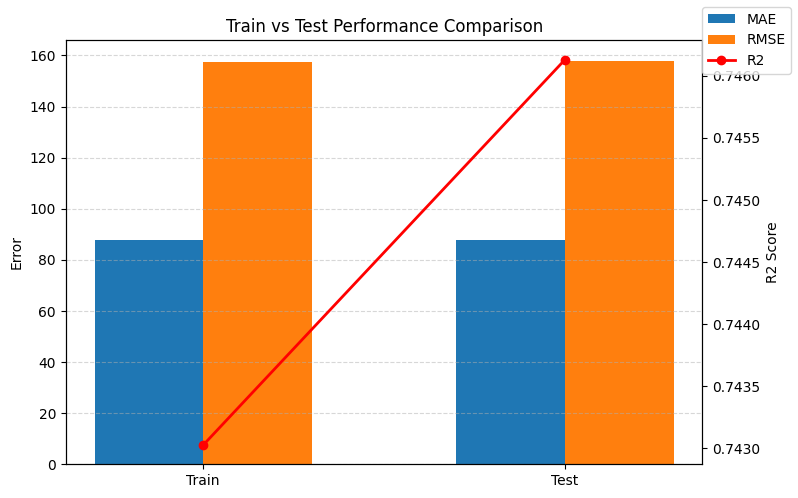

In [66]:
labels = ["Train", "Test"]

mae_vals = [mae_train, mae_test]
rmse_vals = [rmse_train, rmse_test]
r2_vals = [r2_train, r2_test]

x = np.arange(len(labels))
width = 0.3

fig, ax1 = plt.subplots(figsize=(8, 5))

# --- Left axis (Error) ---
ax1.bar(x - width/2, mae_vals, width, label="MAE")
ax1.bar(x + width/2, rmse_vals, width, label="RMSE")
ax1.set_ylabel("Error")

# --- Right axis (R2) ---
ax2 = ax1.twinx()
ax2.plot(x, r2_vals, color="red", marker="o", linewidth=2, label="R2")
ax2.set_ylabel("R2 Score")

# --- X-axis ---
plt.xticks(x, labels)
plt.title("Train vs Test Performance Comparison")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The comparison between training and test performance shows a high level of consistency across all evaluation metrics. Both MAE and RMSE exhibit nearly identical values between the two datasets, while the R² score remains stable with only a negligible difference.

This close alignment indicates that the model generalizes well to unseen data and does not suffer from significant overfitting. The absence of a large performance gap suggests that the learned patterns are robust and transferable beyond the training set.

Additionally, the relatively similar error magnitudes imply that the model maintains stable predictive behavior across different data distributions. This consistency is a strong indicator of reliable model performance in practical deployment scenarios.

Despite the strong generalization, the overall performance level suggests that the model may still be limited by its linear formulation, leaving room for improvement through more expressive models.

### 7.4.2. *Actual vs Predicted*

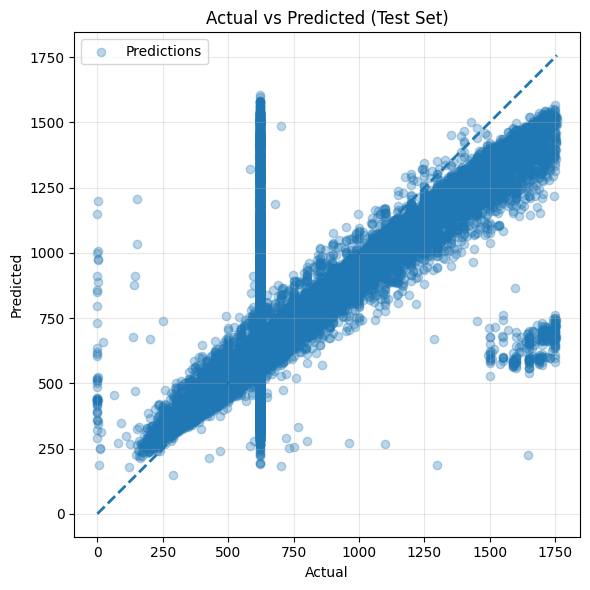

In [67]:
y_test_pred = svm_model.predict(x_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, label="Predictions")

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Test Set)")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The scatter plot shows that most predictions are closely aligned with the diagonal reference line, indicating that the model captures the overall relationship between features and the target variable effectively. This confirms strong predictive performance on the test set.

However, several notable patterns emerge. A vertical concentration of points appears around a specific actual value range, suggesting that the model struggles to differentiate instances with similar feature configurations. Additionally, there are visible clusters at higher actual values where predictions are consistently biased downward, indicating underestimation in the high-rent segment.

The dispersion of points also increases as the target value grows, implying that prediction errors become larger for higher rental prices. This behavior suggests the presence of heteroscedasticity, where variance is not constant across the target range.

Overall, while the model demonstrates good generalization, these patterns indicate that a linear formulation may not fully capture complex relationships in certain regions of the data, particularly for extreme values.

Predictions closely follow the diagonal line, confirming strong generalization. However, visible clustering and increasing dispersion at higher values indicate that the model struggles with high-rent properties and may suffer from heteroscedasticity and limited expressive capacity.

### 7.4.3. *Residual Plot*

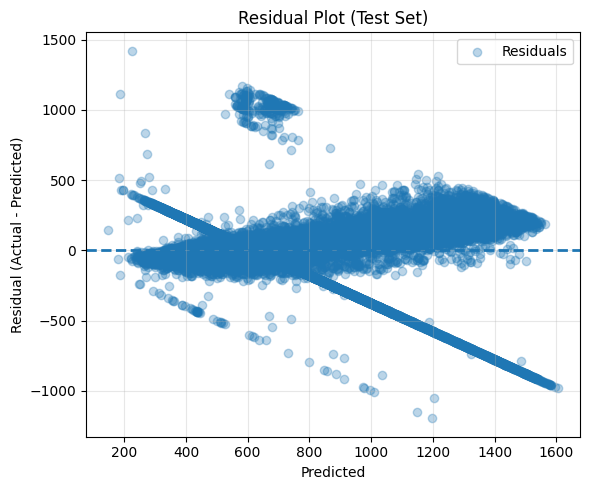

In [68]:
y_test_pred = svm_model.predict(x_test)
residuals = y_test - y_test_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_test_pred, residuals, alpha=0.3, label="Residuals")
plt.axhline(0, linestyle='--', linewidth=2)

plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Test Set)")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The residual plot reveals that errors are not randomly distributed around zero, indicating that the model does not fully capture the underlying structure of the data.

A clear pattern is observed where residuals decrease as predicted values increase. Specifically, the model tends to overestimate at lower predicted values (positive residuals) and underestimate at higher predicted values (negative residuals). This systematic trend suggests the presence of model bias and highlights the limitation of the linear formulation in capturing non-linear relationships.

Additionally, the spread of residuals increases for larger predicted values, forming a funnel-like shape. This indicates heteroscedasticity, where the variance of errors grows with the magnitude of the target variable. Such behavior implies that the model is less reliable when predicting high rental prices.

Another noticeable aspect is the presence of distinct clusters and linear streaks in the residual distribution. These patterns suggest that certain groups of data share similar feature representations but exhibit varying target values, leading to consistent prediction errors. This may be caused by discretized features, missing variables, or latent factors not captured in the current feature set.

Overall, the residual analysis indicates that, despite reasonable predictive performance, the model suffers from systematic bias and variance instability, particularly in higher-value regions.

### 7.4.4. *Error Distribution*

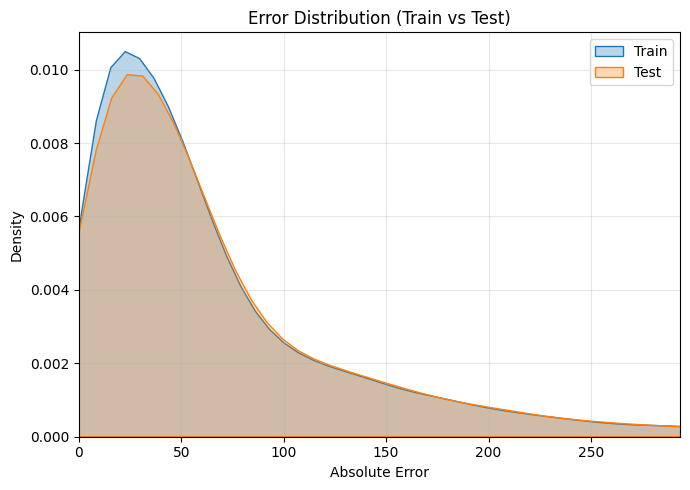

In [69]:
y_train_pred = svm_model.predict(x_train)
y_test_pred  = svm_model.predict(x_test)

error_train = abs(y_train - y_train_pred)
error_test  = abs(y_test - y_test_pred)

plt.figure(figsize=(7, 5))

sns.kdeplot(error_train, label="Train", fill=True, alpha=0.3)
sns.kdeplot(error_test, label="Test", fill=True, alpha=0.3)

plt.xlim(0, np.percentile(error_test, 95))

plt.xlabel("Absolute Error")
plt.ylabel("Density")
plt.title("Error Distribution (Train vs Test)")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



The error distribution shows a high degree of overlap between the training and test sets, indicating that the model maintains consistent predictive behavior across unseen data. This close alignment suggests that the model generalizes well and does not exhibit significant overfitting.

Both distributions are right-skewed, with a strong concentration of errors in the lower range. This indicates that the majority of predictions are relatively accurate, with only a small number of large-error cases.

However, the presence of a long tail extending toward higher error values suggests that the model occasionally produces significant deviations. These outliers may correspond to complex or atypical data points that are not well represented by the current feature set or cannot be effectively captured by a linear model.

Overall, the distribution confirms stable performance while also highlighting the existence of challenging cases that contribute disproportionately to the overall error.

### 7.4.5. *Prediction Error vs Target Value*

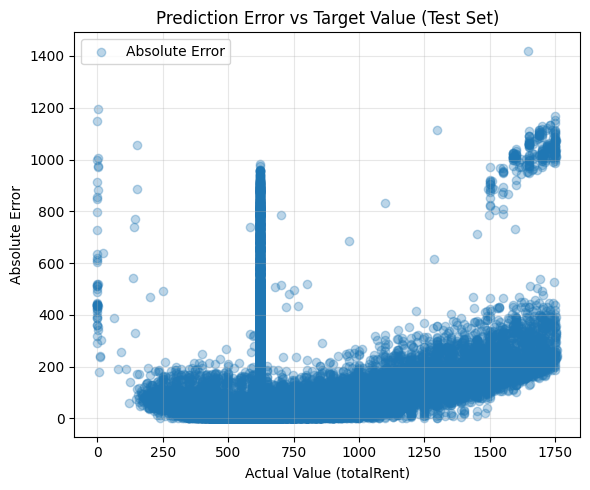

In [70]:
y_test_pred = svm_model.predict(x_test)
abs_error = abs(y_test - y_test_pred)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, abs_error, alpha=0.3, label="Absolute Error")

plt.xlabel("Actual Value (totalRent)")
plt.ylabel("Absolute Error")
plt.title("Prediction Error vs Target Value (Test Set)")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The relationship between prediction error and the target value reveals a clear non-uniform error pattern across different value ranges.

At lower and mid-range values, the model maintains relatively small and stable errors, indicating good predictive accuracy in these regions. However, as the target value increases, the magnitude and dispersion of errors grow significantly. This upward trend indicates that the model struggles to maintain accuracy for high-rent properties.

This pattern is a strong indication of heteroscedasticity, where prediction variance increases with the scale of the target variable. It suggests that the model’s assumptions (particularly linearity and constant variance) do not fully hold across the entire data range.

Additionally, the presence of vertical clusters at specific target values suggests that certain groups of data share similar target values but exhibit varying prediction errors. This may be caused by discretized features, missing explanatory variables, or latent factors that are not captured in the current model.

Overall, while the model performs well for the majority of cases, its reliability decreases in high-value regions, highlighting a limitation in modeling complex or extreme instances.

### 7.4.6. *Learning Behavior Proxy*

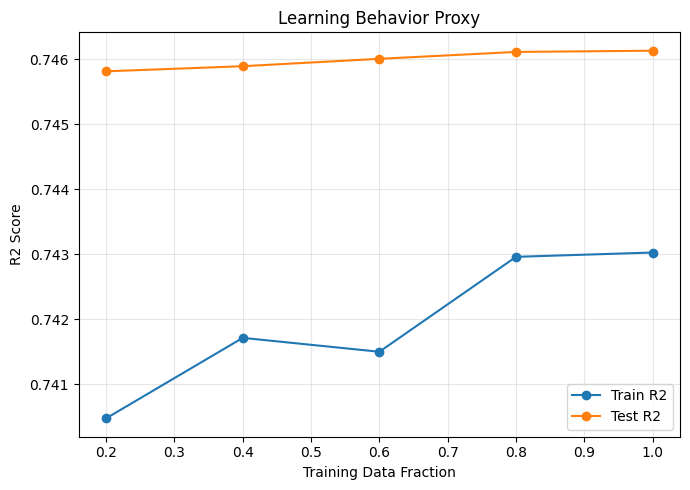

In [71]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

train_scores = []
test_scores = []

for frac in fractions:
    n_samples = int(len(x_train) * frac)

    x_sub = x_train.iloc[:n_samples]
    y_sub = y_train.iloc[:n_samples]

    model = clone(svm_model)
    model.fit(x_sub, y_sub)

    y_train_pred = model.predict(x_sub)
    y_test_pred  = model.predict(x_test)

    train_scores.append(r2_score(y_sub, y_train_pred))
    test_scores.append(r2_score(y_test, y_test_pred))

plt.figure(figsize=(7, 5))

plt.plot(fractions, train_scores, marker='o', label="Train R2")
plt.plot(fractions, test_scores, marker='o', label="Test R2")

plt.xlabel("Training Data Fraction")
plt.ylabel("R2 Score")
plt.title("Learning Behavior Proxy")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The learning behavior plot shows that both training and test performance remain relatively stable as the amount of training data increases.

The test $R^2$ score improves slightly with more data but quickly reaches a plateau, indicating that the model has already captured most of the learnable patterns in the dataset. Similarly, the training $R^2$ increases marginally and remains consistently close to the test performance, suggesting that the model does not suffer from overfitting.

The small gap between training and test curves reflects stable generalization, while the limited improvement across increasing data fractions suggests that the model is approaching its learning capacity.

This behavior indicates that adding more data alone is unlikely to yield significant performance gains. Instead, further improvement would likely require a more expressive model or additional informative features.

## ***7.5. Model Limitations***

Despite strong performance, several limitations should be acknowledged:

- Linearity assumption: Linear SVR may fail to capture complex, non-linear relationships between features.
- Feature dependency: Heavy reliance on baseRent reduces the model’s ability to generalize to scenarios where this feature is unavailable.
- Heteroscedastic errors: Residual patterns suggest that prediction errors may increase with higher rental values.

These limitations highlight potential areas for future improvement.

## ***7.6. Future Improvements***

To further enhance model performance and robustness, several directions can be explored:

- Incorporating non-linear models (e.g., kernel SVR, gradient boosting)
- Performing feature importance analysis to better understand model behavior
- Engineering interaction features to capture non-linear effects
- Evaluating alternative target formulations (e.g., predicting components of rent separately)

## ***7.7. Final Conclusion***

This study investigated the effectiveness of Linear Support Vector Regression (Linear SVR) for predicting apartment rental prices under two feature configurations: excluding and including the `baseRent` feature.

The experimental results demonstrate that feature selection plays a decisive role in model performance. The baseline model, which relies solely on indirect attributes such as structural and locational features, achieves only moderate predictive accuracy, indicating that these features alone are insufficient to fully capture the variability of rental prices. In contrast, incorporating `baseRent` leads to a substantial improvement across all evaluation metrics, significantly reducing prediction errors and increasing the model’s explanatory power.

However, this improvement must be interpreted with caution. The feature `baseRent` is not merely correlated with the target variable `totalRent`, but is likely a direct component of it. As a result, the enhanced performance of the second model reflects a proxy relationship rather than a genuine increase in the model’s ability to infer complex patterns. From a statistical perspective, this introduces a potential target leakage effect, where the learning task becomes closer to reconstructing a near-deterministic relationship instead of discovering underlying structure.

Further analysis of prediction behavior and residual patterns reveals that, despite improved accuracy, the Linear SVR model remains limited in its capacity to capture non-linear relationships, particularly at higher rental values where error variance increases. This suggests that the model has reached its expressive limits, as also evidenced by the early plateau observed in the learning behavior analysis.

Overall, the final model achieves a strong balance between simplicity and predictive performance under the given feature configuration. However, the findings highlight an important distinction between predictive accuracy and meaningful learning. While the inclusion of `baseRent` yields strong numerical results, it reduces the problem complexity in a way that may not generalize to real-world scenarios where such direct information is unavailable.

These insights emphasize the importance of careful feature design and critical evaluation of model performance, especially in cases where certain features may implicitly encode the target variable. Future work should explore more expressive models and alternative problem formulations to better capture the underlying dynamics of rental pricing without relying on proxy features.